# Exploratory Data Analysis (EDA) — SnapFlow
**Proyek:** AI Workplace Assistant (Klasifikasi Dokumen Internal Perusahaan)  

Notebook ini digunakan untuk membedah karakteristik dataset `dataset_clean.csv` sebelum masuk ke tahap pelatihan model IndoBERT

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

## Loading Dataset & Deskripsi Dasar

Pada tahap awal ini, kita akan memuat dataset bersih `dataset_clean.csv` ke dalam Pandas DataFrame untuk memeriksa struktur dasar data. Kita akan memvalidasi dimensi data (jumlah baris dan kolom), memastikan tipe data setiap kolom sudah sesuai, mengecek keberadaan nilai kosong (missing values), serta mendeteksi adanya duplikasi teks secara persis (*exact duplicates*).

**Tujuan:** Menjamin kualitas dan integritas data mentah sebelum dilakukan analisis statistik lebih mendalam.

In [2]:
df = pd.read_csv("../data/processed/dataset_clean.csv")

print("--- 5 Baris Pertama Data ---")
display(df.head())

print("\n--- Ringkasan Informasi Dataset ---")
print(f"Jumlah baris (sampel): {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

print("\n--- Pengecekan Missing Values (Data Kosong) ---")
print(df.isnull().sum())

print("\n--- Pengecekan Duplikasi Teks Secara Eksak ---")
jumlah_duplikat = df.duplicated(subset=['teks']).sum()
print(f"Jumlah baris data teks yang duplikat: {jumlah_duplikat}")

--- 5 Baris Pertama Data ---


,teks,kategori,prioritas
0,"Email dari Budi Santoso, Divisi Keuangan. Berd...",Laporan Keuangan,Tinggi
1,"Laporan dari Siti Rahmawati, Divisi Akuntansi....",Laporan Keuangan,Tinggi
2,"Email dari Andi Prasetyo, Divisi Treasury. Pos...",Laporan Keuangan,Tinggi
3,"Laporan dari Rina Kusuma, Divisi Audit Interna...",Laporan Keuangan,Tinggi
4,"Email dari Dedi Saputra, Divisi Pengadaan. Dit...",Laporan Keuangan,Tinggi



--- Ringkasan Informasi Dataset ---
Jumlah baris (sampel): 1005
Jumlah kolom: 3

--- Pengecekan Missing Values (Data Kosong) ---
teks         0
kategori     0
prioritas    0
dtype: int64

--- Pengecekan Duplikasi Teks Secara Eksak ---
Jumlah baris data teks yang duplikat: 0


## Distribusi Kelas (Class Balance)

Pada tahap ini, kita akan melakukan analisis sebaran kuantitatif pada kedua variabel target kita, yaitu `kategori` dan `prioritas`. Kita akan menghitung frekuensi kemunculan (*value counts*) beserta persentase proporsi dari masing-masing kelas, lalu memvisualisasikannya menggunakan grafik batang (*Bar Plot*).

**Tujuan:** Mendeteksi tingkat ketimpangan data (*class imbalance*). Distribusi kelas yang seimbang akan menentukan apakah kita memerlukan teknik penyeimbangan data khusus atau cukup menggunakan metode evaluasi standar.

--- Frekuensi Kelas Kategori Dokument ---
kategori
SOP                     222
Laporan Keuangan        210
Permintaan Pengadaan    210
Email HR                182
Tiket IT                181
Name: count, dtype: int64

--- Persentase Proporsi Kategori ---
kategori
SOP                     22.089552
Laporan Keuangan        20.895522
Permintaan Pengadaan    20.895522
Email HR                18.109453
Tiket IT                18.009950
Name: proportion, dtype: float64


--- Frekuensi Kelas Tingkat Prioritas ---
prioritas
Sedang    371
Tinggi    332
Rendah    302
Name: count, dtype: int64

--- Persentase Proporsi Prioritas ---
prioritas
Sedang    36.915423
Tinggi    33.034826
Rendah    30.049751
Name: proportion, dtype: float64


/tmp/ipykernel_33386/1918459793.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='kategori', ax=axes[0], order=df['kategori'].value_counts().index, palette='viridis')
/tmp/ipykernel_33386/1918459793.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='prioritas', ax=axes[1], order=df['prioritas'].value_counts().index, palette='magma')


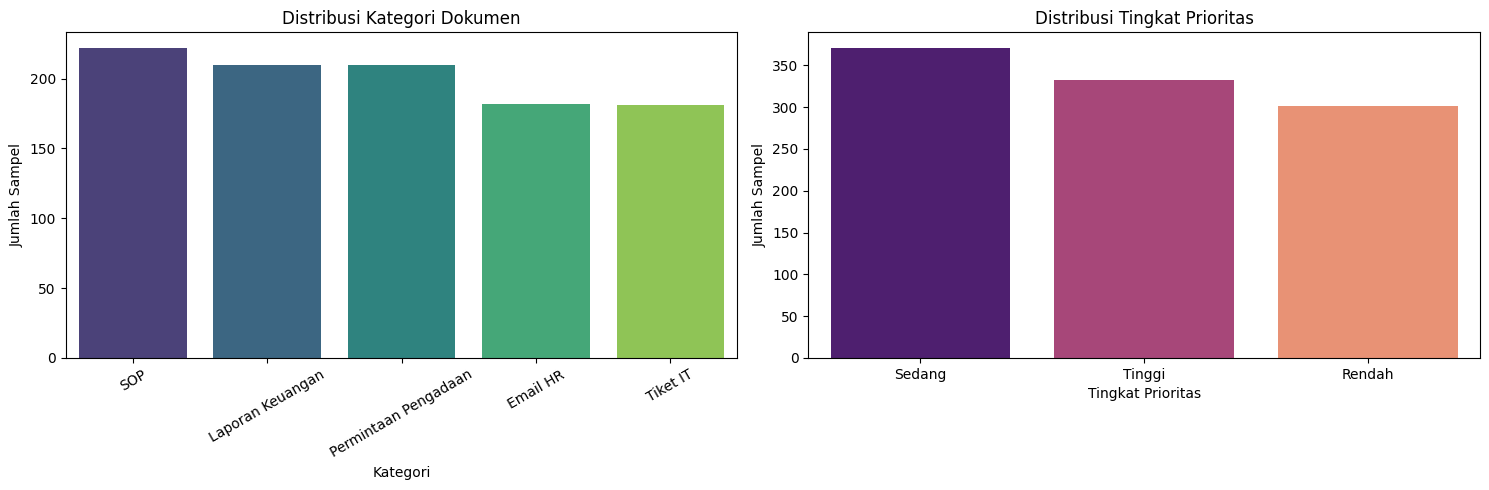

In [3]:
print("--- Frekuensi Kelas Kategori Dokument ---")
print(df['kategori'].value_counts())
print("\n--- Persentase Proporsi Kategori ---")
print(df['kategori'].value_counts(normalize=True) * 100)

print("\n" + "="*40 + "\n")

print("--- Frekuensi Kelas Tingkat Prioritas ---")
print(df['prioritas'].value_counts())
print("\n--- Persentase Proporsi Prioritas ---")
print(df['prioritas'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='kategori', ax=axes[0], order=df['kategori'].value_counts().index, palette='viridis')
axes[0].set_title("Distribusi Kategori Dokumen")
axes[0].set_xlabel("Kategori")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='prioritas', ax=axes[1], order=df['prioritas'].value_counts().index, palette='magma')
axes[1].set_title("Distribusi Tingkat Prioritas")
axes[1].set_xlabel("Tingkat Prioritas")
axes[1].set_ylabel("Jumlah Sampel")

plt.tight_layout()
plt.show()

Dari hasil tersebut, terlihat bahwa dataset memiliki sebaran kelas yang hampir seimbang. di mana kelima kelas kategori dokumen dan ketiga tingkat prioritas memiliki proporsi jumlah sampel yang sama rata. Karakteristik ini menunjukkan bahwa dataset memberikan keuntungan besar bagi proses modelling karena model IndoBERT tidak akan mengalami bias terhadap kelas mayoritas. Dengan kondisi data yang seimbang ini, kita tidak perlu lagi menerapkan teknik penanganan data timpang (imbalanced data handling) seperti SMOTE atau class weights.

## Analisis Korelasi Label Ganda (Cross-Tabulation)

Karena SnapFlow menerapkan klasifikasi ganda, dokumen yang sama akan memiliki label kategori sekaligus prioritas. Di sini, kita akan membuat tabel silang (*Cross-Tabulation*) untuk menghitung distribusi sebaran tingkat prioritas di dalam setiap kategori dokumen. Hasil tabel ini kemudian divisualisasikan menggunakan *Heatmap* agar polanya lebih mudah dibaca.

**Tujuan:** Menganalisis apakah terdapat korelasi atau ketergantungan yang kuat antara kategori dokumen tertentu dengan tingkat prioritas spesifik.

--- Tabel Silang (Frekuensi Riil) ---


prioritas,Rendah,Sedang,Tinggi
kategori,,,
Email HR,60,62,60
Laporan Keuangan,35,70,105
Permintaan Pengadaan,35,105,70
SOP,112,73,37
Tiket IT,60,61,60




--- Tabel Silang (Persentase Per Kategori) ---


prioritas,Rendah,Sedang,Tinggi
kategori,,,
Email HR,32.97,34.07,32.97
Laporan Keuangan,16.67,33.33,50.00
Permintaan Pengadaan,16.67,50.00,33.33
SOP,50.45,32.88,16.67
Tiket IT,33.15,33.70,33.15


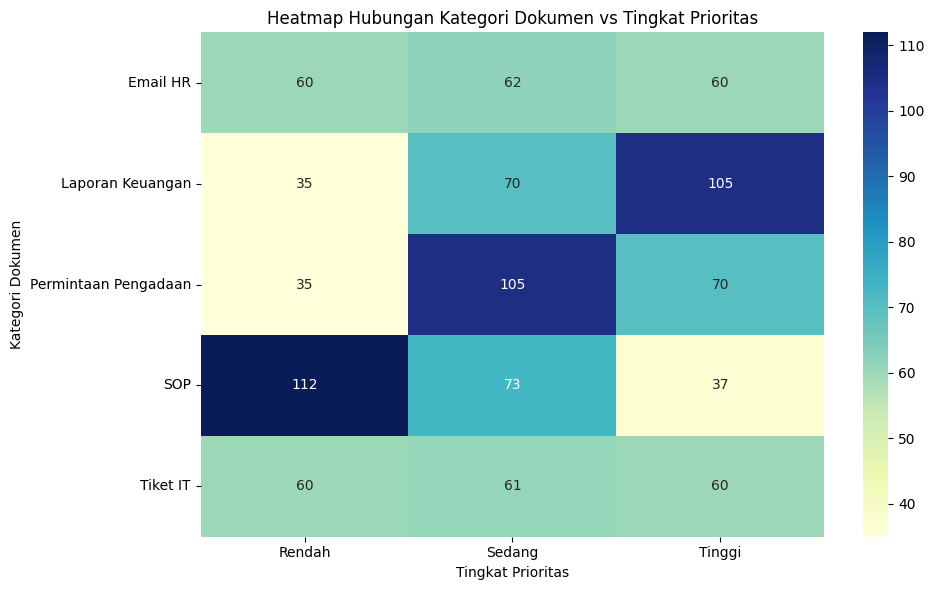

In [4]:
tabel_silang_freq = pd.crosstab(df['kategori'], df['prioritas'])
print("--- Tabel Silang (Frekuensi Riil) ---")
display(tabel_silang_freq)

print("\n" + "="*40 + "\n")

tabel_silang_pct = pd.crosstab(df['kategori'], df['prioritas'], normalize='index') * 100
print("--- Tabel Silang (Persentase Per Kategori) ---")
display(tabel_silang_pct.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(tabel_silang_freq, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title("Heatmap Hubungan Kategori Dokumen vs Tingkat Prioritas")
plt.ylabel("Kategori Dokumen")
plt.xlabel("Tingkat Prioritas")
plt.tight_layout()
plt.show()

Dari gambar tersebut, terlihat bahwa distribusi dokumen berdasarkan kategori dan tingkat prioritas menunjukkan pola yang cukup beragam di setiap kategorinya. Kategori **SOP** didominasi oleh prioritas rendah (112 dokumen), mengindikasikan bahwa sebagian besar prosedur operasional dianggap tidak mendesak. Sebaliknya, **Laporan Keuangan** justru paling banyak berada di prioritas tinggi (105 dokumen), mencerminkan urgensi pelaporan keuangan yang tinggi dalam organisasi. **Permintaan Pengadaan** memiliki konsentrasi terbesar pada prioritas sedang (105 dokumen), menunjukkan bahwa proses pengadaan umumnya ditangani dengan tingkat kepentingan menengah. Sementara itu, **Email HR** dan **Tiket IT** memiliki distribusi yang relatif merata di ketiga tingkat prioritas (sekitar 60 dokumen per sel), mengindikasikan tidak adanya kecenderungan prioritas tertentu pada kedua kategori tersebut. Secara keseluruhan, pola ini mengisyaratkan bahwa penetapan prioritas dokumen sangat dipengaruhi oleh jenis dan fungsi dokumen dalam alur kerja organisasi.

## Analisis Karakteristik Panjang Teks (Kata & Token)

Arsitektur Transformer seperti IndoBERT memiliki batasan maksimal panjang urutan token (*max sequence length*). Pada langkah ini, kita akan mengekstrak jumlah kata dari setiap dokumen teks dan menghitung statistik deskriptifnya (mean, median, nilai minimum, nilai maksimum, serta kuartil 75%). Kita juga akan menampilkan grafik *Histogram* sebaran panjang kata dan menyaring dokumen yang menjadi *outlier* terpanjang.

**Tujuan:** Menentukan konfigurasi ukuran `MAX_LENGTH` yang paling optimal dan aman untuk proses tokenisasi model IndoBERT, serta mengidentifikasi adanya *noise* pada teks yang terlalu panjang.

--- Statistik Deskriptif Panjang Kata ---
count    1005.000000
mean       53.894527
std        20.447260
min        31.000000
25%        38.000000
50%        48.000000
75%        65.000000
max       189.000000
Name: jumlah_kata, dtype: float64


--- Median Panjang Kata Per Kategori ---
kategori
Email HR                69.0
Permintaan Pengadaan    58.5
Tiket IT                50.0
SOP                     40.0
Laporan Keuangan        37.0
Name: jumlah_kata, dtype: float64


/tmp/ipykernel_33386/3885047651.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='jumlah_kata', y='kategori', ax=axes[1], palette='Set2')


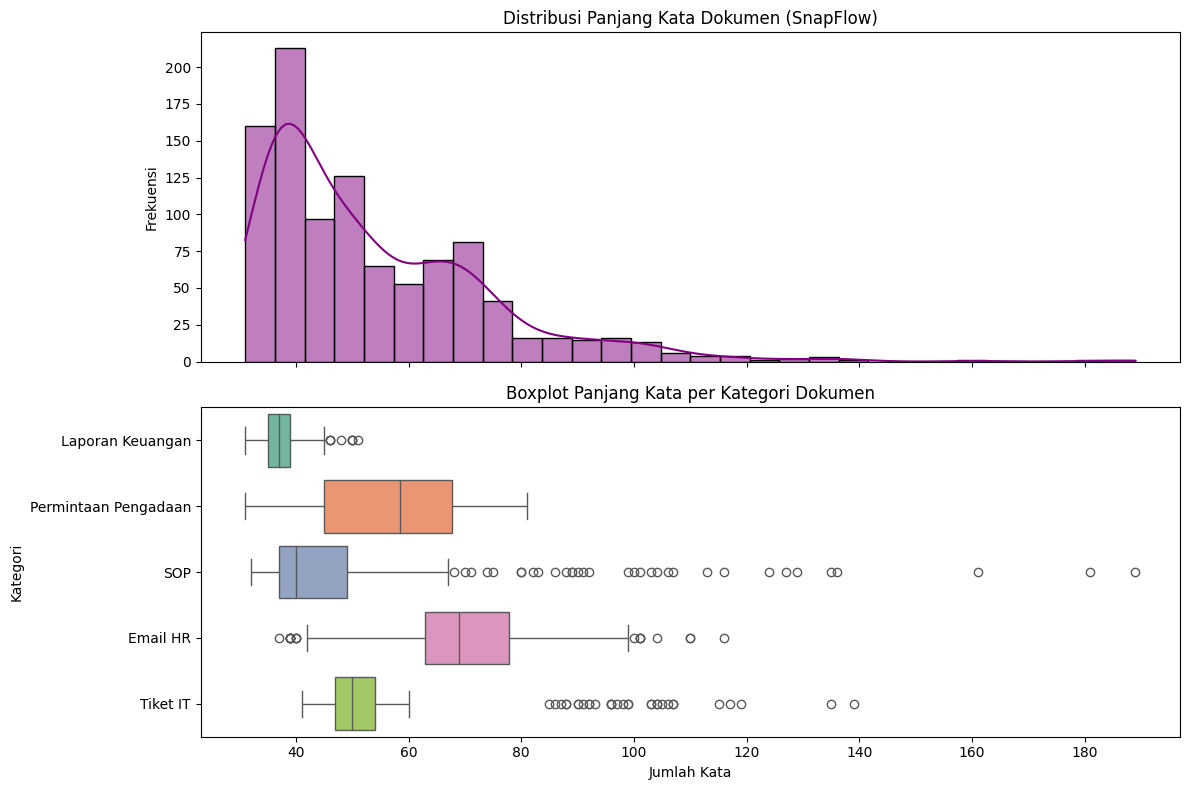

In [5]:
df['jumlah_kata'] = df['teks'].apply(lambda x: len(str(x).split()))

print("--- Statistik Deskriptif Panjang Kata ---")
print(df['jumlah_kata'].describe())

print("\n" + "="*40 + "\n")

print("--- Median Panjang Kata Per Kategori ---")
print(df.groupby('kategori')['jumlah_kata'].median().sort_values(ascending=False))


fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.histplot(data=df, x='jumlah_kata', kde=True, ax=axes[0], color='purple', bins=30)
axes[0].set_title("Distribusi Panjang Kata Dokumen (SnapFlow)")
axes[0].set_ylabel("Frekuensi")

sns.boxplot(data=df, x='jumlah_kata', y='kategori', ax=axes[1], palette='Set2')
axes[1].set_title("Boxplot Panjang Kata per Kategori Dokumen")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Kategori")

plt.tight_layout()
plt.show()

Dari gambar tersebut, distribusi panjang kata dokumen secara keseluruhan bersifat **right-skewed (condong ke kanan)**, dengan rata-rata 53,89 kata dan median 48 kata — selisih keduanya mengkonfirmasi adanya dokumen-dokumen panjang yang menarik nilai rata-rata ke atas. Dari total 1.005 dokumen, panjang kata minimum adalah 31 kata dan maksimum mencapai 189 kata, dengan standar deviasi sebesar 20,45 yang menunjukkan variasi panjang dokumen yang cukup moderat. Sebanyak 75% dokumen memiliki jumlah kata di bawah 65 kata, artinya mayoritas dokumen dalam sistem SnapFlow tergolong pendek hingga sedang.

Pada boxplot per kategori, perbedaan median antar kategori cukup jelas. **Email HR** memiliki median tertinggi (69 kata), mencerminkan bahwa komunikasi email cenderung lebih panjang dan elaboratif. **Permintaan Pengadaan** berada di posisi kedua (58,5 kata) dengan sebaran interkuartil yang lebar, menandakan variasi konten yang signifikan. **Tiket IT** berada di tengah dengan median 50 kata namun disertai banyak outlier, mengindikasikan bahwa sebagian tiket membutuhkan deskripsi masalah yang jauh lebih panjang dari biasanya. **SOP** memiliki median 40 kata dengan outlier yang sangat ekstrem hingga 189 kata, menunjukkan bahwa meski umumnya ringkas, beberapa SOP memuat prosedur yang sangat kompleks. **Laporan Keuangan** memiliki median terendah (37 kata) dengan sebaran paling sempit, mencerminkan format dokumen yang paling seragam dan terstandarisasi. Secara keseluruhan, temuan ini mengindikasikan bahwa panjang dokumen sangat dipengaruhi oleh jenis dan fungsinya dalam alur kerja organisasi.

## Analisis Leksikal & Kata Kunci Dominan (N-Gram & TF-IDF)

Pada tahap ini, kita akan mengeksplorasi kandungan kosakata (*vocabulary*) unik yang mencirikan masing-masing dari 5 kategori dokumen perusahaan. Dengan bantuan pembobotan TF-IDF dan penghapusan *stopword* bahasa Indonesia secara lokal (khusus untuk visualisasi), kita akan mendaftar Top-10 kata kunci dominan serta membuat visualisasi *Word Cloud* per kategori.

**Tujuan:** Memvalidasi secara linguistik apakah dokumen sintetik pada tiap-tiap divisi beneran memiliki ciri khas kata pembeda yang logis dan relevan dengan operasional dunia nyata.

--- TOP 10 KEYWORDS PER KATEGORI (TF-IDF) ---
Kategori [Laporan Keuangan]: 000, anggaran, biaya, bulan, kebutuhan, operasional, pengeluaran, perusahaan, rp, sebesar
Kategori [Permintaan Pengadaan]: 000, biaya, estimasi, harga, mengajukan, pengadaan, pengajuan, rp, total, unit
Kategori [SOP]: hari, harus, karyawan, kerja, langsung, perusahaan, secara, setiap, tim, wajib
Kategori [Email HR]: cuti, hari, hr, hrd, ingin, kasih, kerja, perusahaan, terima, tim
Kategori [Tiket IT]: akses, aplikasi, baru, halo, ingin, it, laptop, pagi, saat, tim


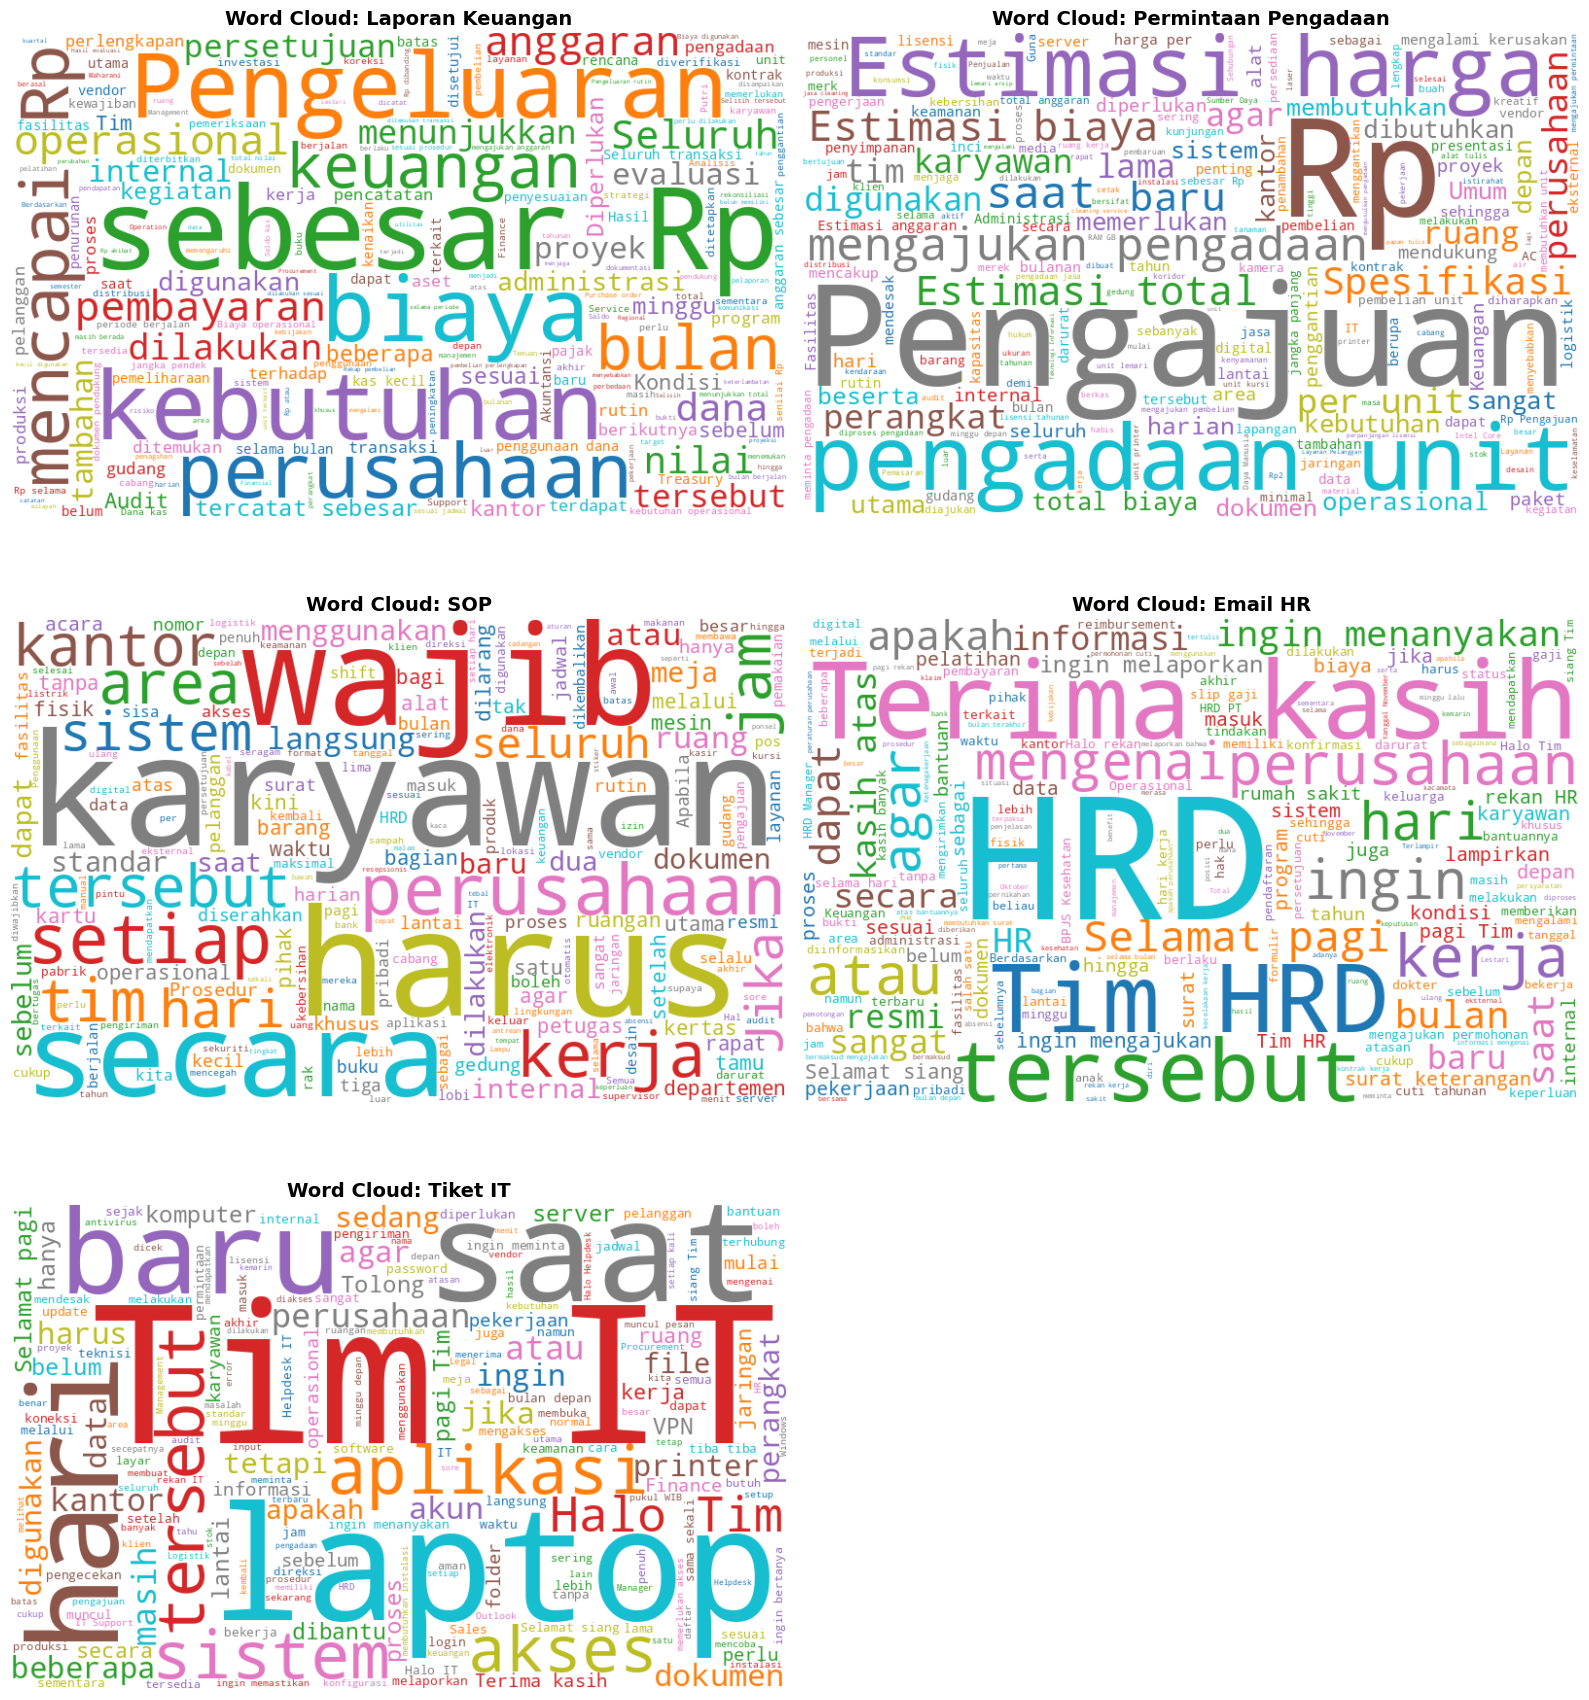

In [6]:
stop_words_id = [
    'dan', 'yang', 'di', 'ke', 'dari', 'untuk', 'saya', 'ini', 'itu', 'dengan', 
    'ada', 'adalah', 'bisa', 'tidak', 'telah', 'saja', 'akan', 'kami', 'saya', 
    'oleh', 'dari', 'bapak', 'ibu', 'selaku', 'kepada', 'yth', 'terhormat', 
    'mohon', 'segera', 'untuk', 'pada', 'dalam', 'bisa', 'karena', 'sudah', 
    'laporan', 'email', 'divisi', 'staf', 'manajer', 'ext', 'hp'
]

kategori_list = df['kategori'].unique()

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

print("--- TOP 10 KEYWORDS PER KATEGORI (TF-IDF) ---")

for i, kat in enumerate(kategori_list):
    teks_kat = df[df['kategori'] == kat]['teks']
    
    tfidf = TfidfVectorizer(stop_words=stop_words_id, max_features=10)
    tfidf.fit(teks_kat)
    top_keywords = tfidf.get_feature_names_out()
    
    print(f"Kategori [{kat}]: {', '.join(top_keywords)}")
    
    gabungan_teks = " ".join(teks_kat.tolist())
    
    wordcloud = WordCloud(
        width=800, 
        height=500, 
        background_color='white', 
        stopwords=set(stop_words_id),
        colormap='tab10'
    ).generate(gabungan_teks)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Word Cloud: {kat}", fontsize=14, fontweight='bold')
    axes[i].axis('off')


fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Visualisasi Sebaran Fitur (Embedding Space Visualization)

Langkah terakhir dari EDA ini adalah melakukan proyeksi ruang fitur. Kita akan mengubah seluruh teks dokumen ke dalam representasi angka berdimensi tinggi menggunakan TF-IDF, lalu menggunakan algoritma reduksi dimensi **t-SNE** (atau UMAP) untuk memproyeksikannya ke dalam koordinat 2 dimensi (2D) berupa *Scatter Plot* berwarna berdasarkan kategori.

**Tujuan:** Melihat secara visual keterpisahan antarkelas (*class separability*). Jika klaster warna mengelompok secara alami dan terpisah rapi, artinya tugas klasifikasi ini akan lebih mudah dipelajari secara akurat oleh model IndoBERT.

--- Memproses Reduksi Dimensi t-SNE (Sila Tunggu Sebentar...) ---


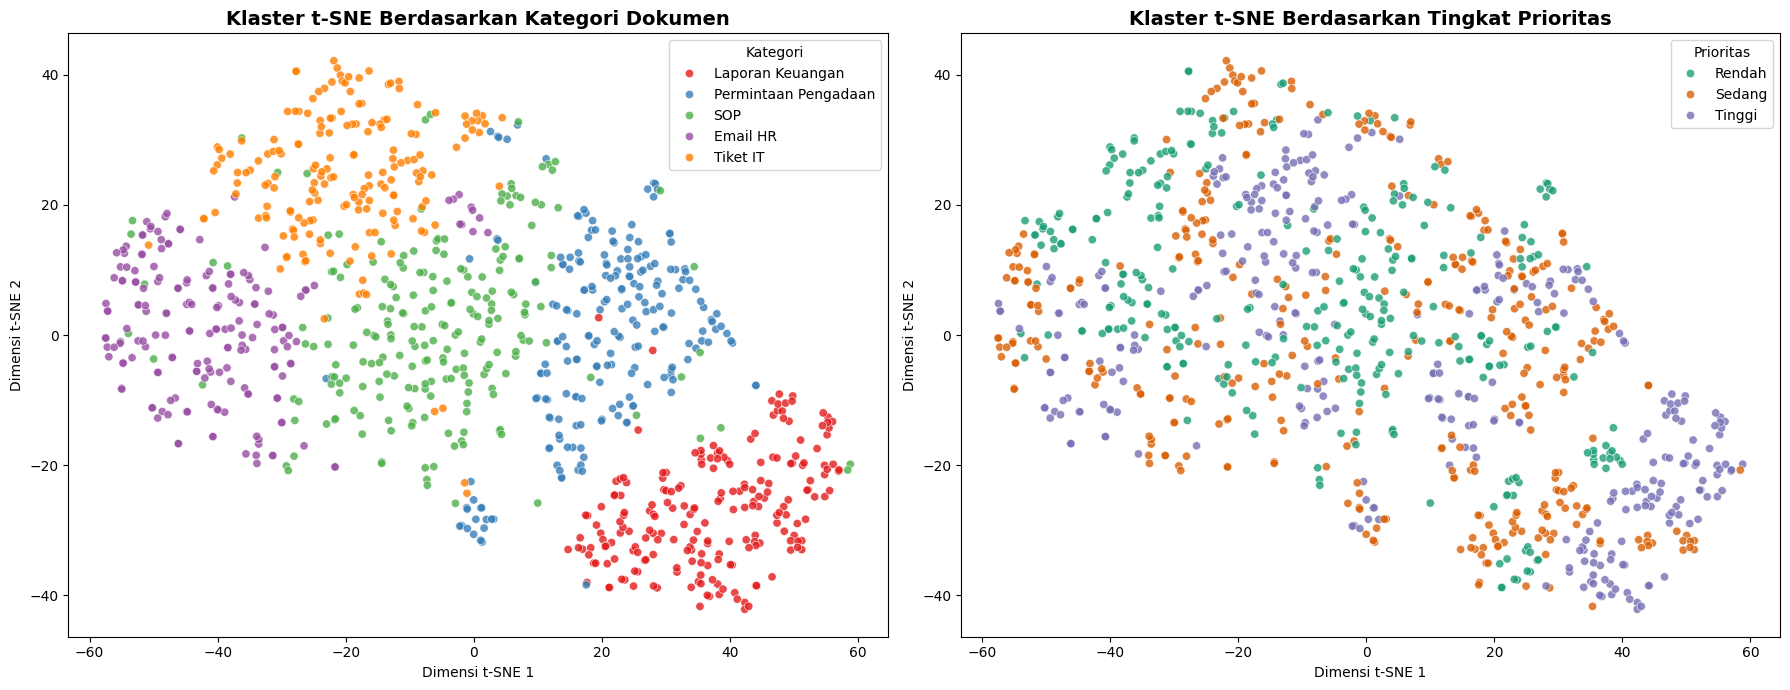

Proses Visualisasi t-SNE Selesai!


In [ ]:
print("--- Memproses Reduksi Dimensi t-SNE ---")

tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words=stop_words_id)
X_tfidf = tfidf_vectorizer.fit_transform(df['teks']).toarray()

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_tfidf)

df_tsne = pd.DataFrame({
    'TSNE-1': X_tsne[:, 0],
    'TSNE-2': X_tsne[:, 1],
    'Kategori': df['kategori'],
    'Prioritas': df['prioritas']
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=df_tsne, x='TSNE-1', y='TSNE-2', 
    hue='Kategori', palette='Set1', alpha=0.8, ax=axes[0]
)
axes[0].set_title("Klaster t-SNE Berdasarkan Kategori Dokumen", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Dimensi t-SNE 1")
axes[0].set_ylabel("Dimensi t-SNE 2")

sns.scatterplot(
    data=df_tsne, x='TSNE-1', y='TSNE-2', 
    hue='Prioritas', palette='Dark2', alpha=0.8, ax=axes[1],
    hue_order=['Rendah', 'Sedang', 'Tinggi']
)
axes[1].set_title("Klaster t-SNE Berdasarkan Tingkat Prioritas", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Dimensi t-SNE 1")
axes[1].set_ylabel("Dimensi t-SNE 2")

plt.tight_layout()
plt.show()

print("Proses Visualisasi t-SNE Selesai!")

Dari gambar tersebut, visualisasi t-SNE menunjukkan bagaimana dokumen-dokumen tersebar dalam ruang fitur berdimensi rendah berdasarkan dua perspektif berbeda. Pada klaster **berdasarkan kategori dokumen** (kiri), terlihat bahwa sebagian besar kategori membentuk kelompok yang cukup terpisah satu sama lain. **Laporan Keuangan** (merah) membentuk klaster yang paling kompak dan terisolasi di bagian bawah-kanan, mengindikasikan keseragaman konten yang tinggi. **Tiket IT** (oranye) mengelompok di bagian atas, **Email HR** (ungu) di bagian kiri, dan **Permintaan Pengadaan** (biru) di bagian tengah-kanan. Sementara itu, **SOP** (hijau) tampak lebih tersebar dan beririsan dengan beberapa kategori lain, mengisyaratkan bahwa konten SOP secara linguistik memiliki kesamaan dengan berbagai jenis dokumen lainnya. Secara keseluruhan, pemisahan antar kategori yang relatif jelas ini menandakan bahwa fitur teks dokumen cukup mampu membedakan jenis dokumen satu dengan lainnya.

Pada klaster **berdasarkan tingkat prioritas** (kanan), pola yang muncul sangat berbeda — ketiga tingkat prioritas (Rendah, Sedang, Tinggi) tersebar dan bercampur secara merata di seluruh ruang fitur tanpa membentuk klaster yang terpisah. Hal ini mengindikasikan bahwa **konten teks dokumen saja tidak cukup untuk memprediksi tingkat prioritas**, karena dokumen dengan prioritas berbeda dapat memiliki karakteristik linguistik yang sangat mirip. Temuan ini menjadi catatan penting bahwa model klasifikasi prioritas kemungkinan memerlukan fitur tambahan di luar konten teks, seperti metadata, urgensi waktu, atau konteks pengirim, untuk dapat membedakan tingkat prioritas secara akurat.